# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [2]:
# Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter consumers with no transaction or balance information
consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [3]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time_fix
- Using cached result for balance_over_time

Total Created Features:  266


## 2 Split Data

In [4]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7591
No validation set created.
Test set size: 2531


## 3. All Model Performances

In [5]:
summary_table = evaluate_feature_model_combinations(train_df, test_df, all_feature_columns)

Evaluating: Feature Selection = all_features, Model = xgboost
Evaluating: Feature Selection = all_features, Model = gradient_boosting
Evaluating: Feature Selection = all_features, Model = random_forest
Evaluating: Feature Selection = all_features, Model = logistic
Evaluating: Feature Selection = mutual_info, Model = xgboost
Evaluating: Feature Selection = mutual_info, Model = gradient_boosting
Evaluating: Feature Selection = mutual_info, Model = random_forest
Evaluating: Feature Selection = mutual_info, Model = logistic
Evaluating: Feature Selection = random_forest, Model = xgboost
Evaluating: Feature Selection = random_forest, Model = gradient_boosting
Evaluating: Feature Selection = random_forest, Model = random_forest
Evaluating: Feature Selection = random_forest, Model = logistic
Evaluating: Feature Selection = xgboost, Model = xgboost
Evaluating: Feature Selection = xgboost, Model = gradient_boosting
Evaluating: Feature Selection = xgboost, Model = random_forest
Evaluating: Featur

In [6]:
summary_table

,Feature Selection,Model,Test Accuracy,Test Balanced Accuracy,Test ROC AUC
0,all_features,xgboost,0.78,0.71,0.79
1,all_features,gradient_boosting,0.92,0.51,0.81
2,all_features,random_forest,0.92,0.52,0.78
3,all_features,logistic,0.67,0.68,0.71
4,mutual_info,xgboost,0.75,0.71,0.80
5,mutual_info,gradient_boosting,0.92,0.53,0.80
6,mutual_info,random_forest,0.92,0.52,0.79
7,mutual_info,logistic,0.63,0.69,0.73
8,random_forest,xgboost,0.76,0.72,0.79
9,random_forest,gradient_boosting,0.92,0.54,0.81


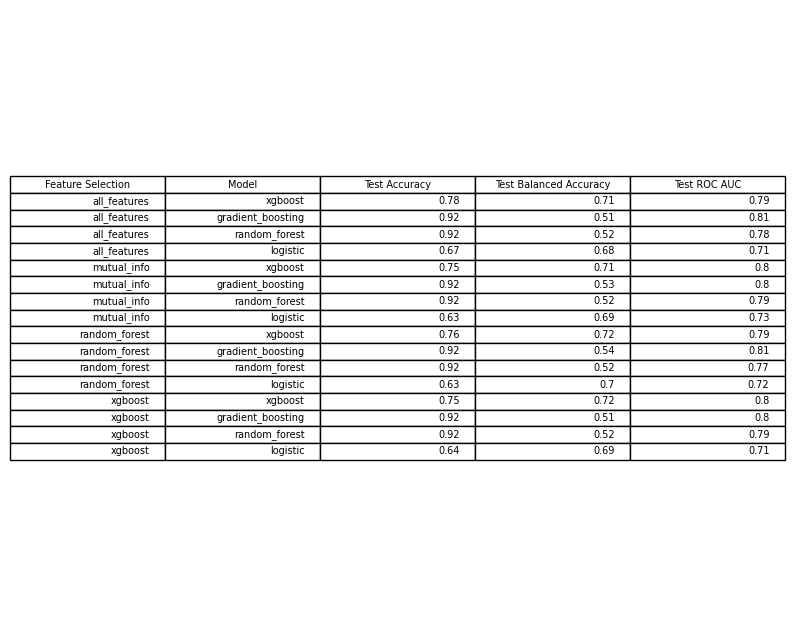

In [ ]:
# Set up the matplotlib figure and axis
fig, ax = plt.subplots(figsize=(len(summary_table.columns) * 2, len(summary_table) * 0.5))
ax.axis('tight')
ax.axis('off')

# Create the table plot from the DataFrame
table = ax.table(cellText=summary_table.values, colLabels=summary_table.columns, loc='center')
 
# Save the figure as an image file
plt.show()

## 4. Individual Model Training

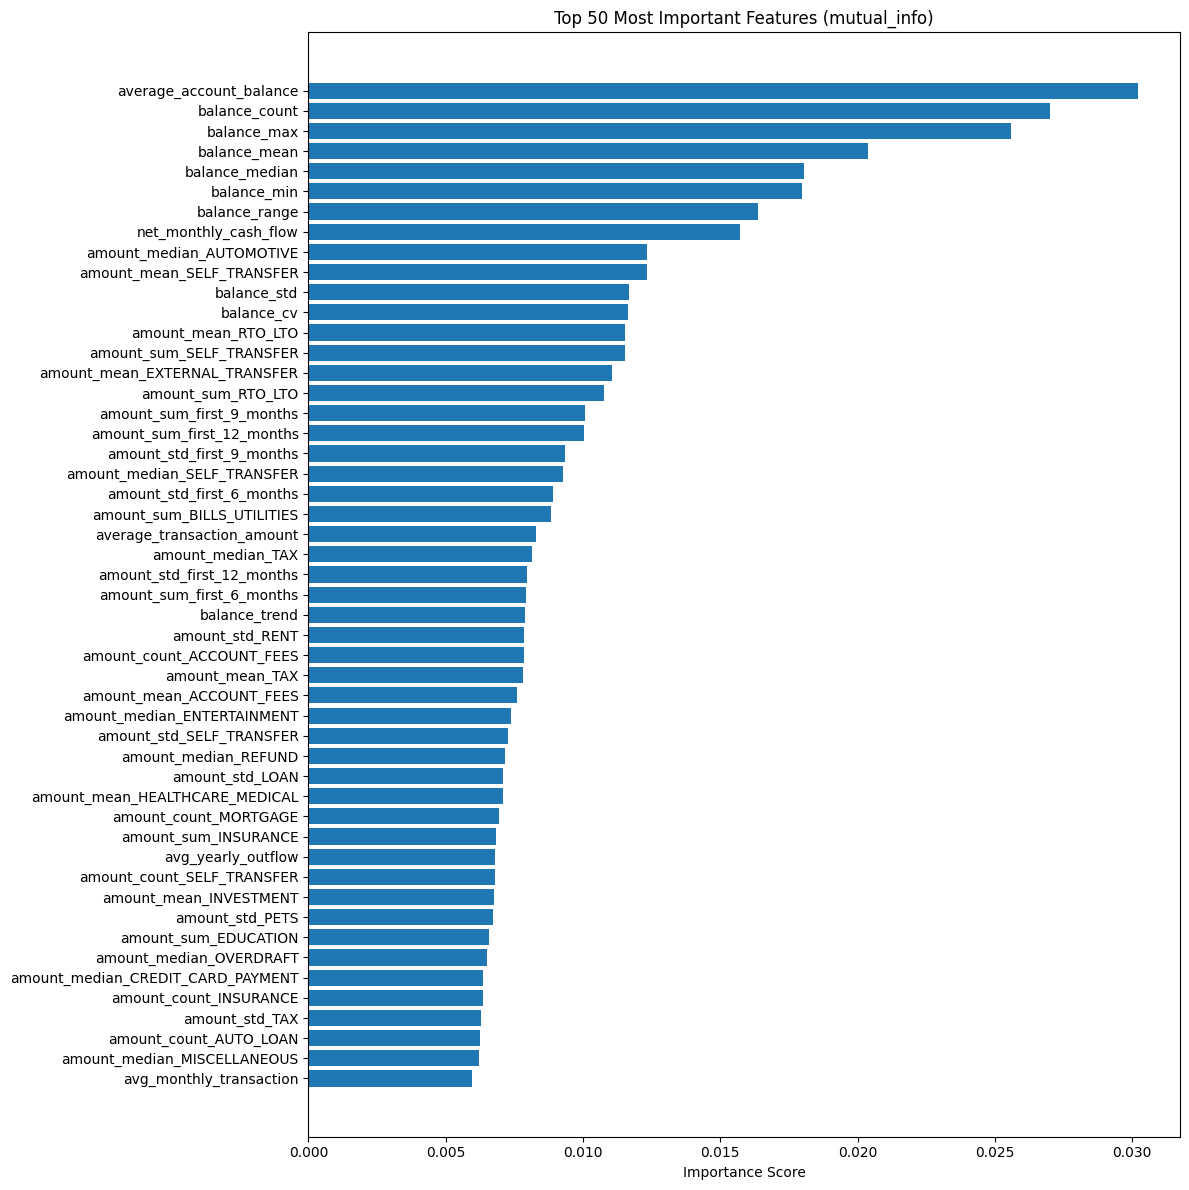

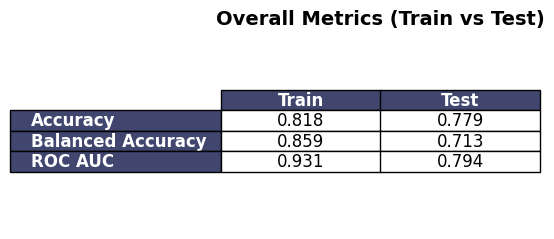


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.989416  0.809029  0.890176  6933.000000  0.960876  0.791917  0.868254  2326.000000
1.0           0.311134  0.908815  0.463566   658.000000  0.211726  0.634146  0.317460   205.000000
accuracy      0.817679  0.817679  0.817679     0.817679  0.779139  0.779139  0.779139     0.779139
macro avg     0.650275  0.858922  0.676871  7591.000000  0.586301  0.713032  0.592857  2531.000000
weighted avg  0.930622  0.817679  0.853197  7591.000000  0.900198  0.779139  0.823642  2531.000000


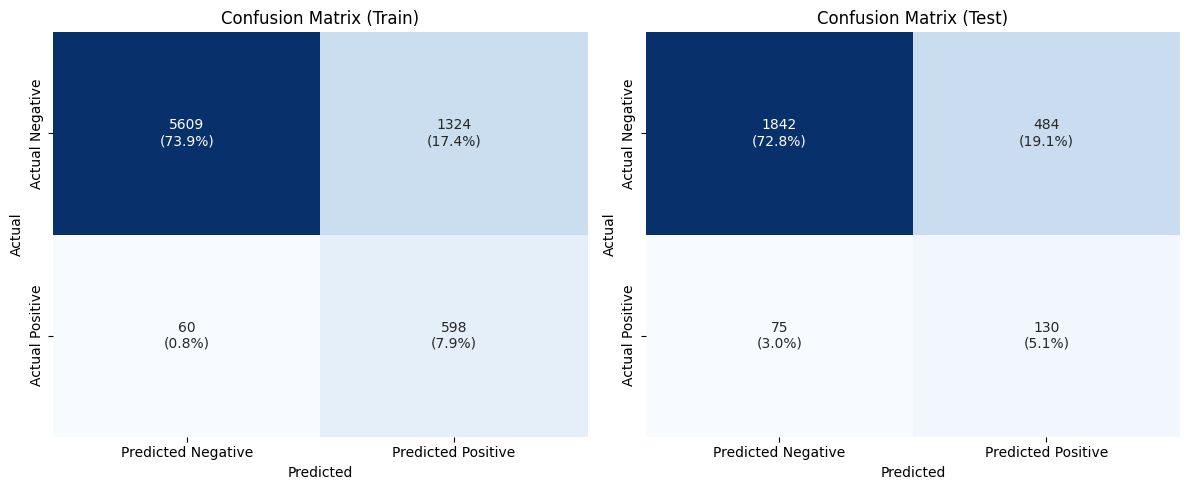

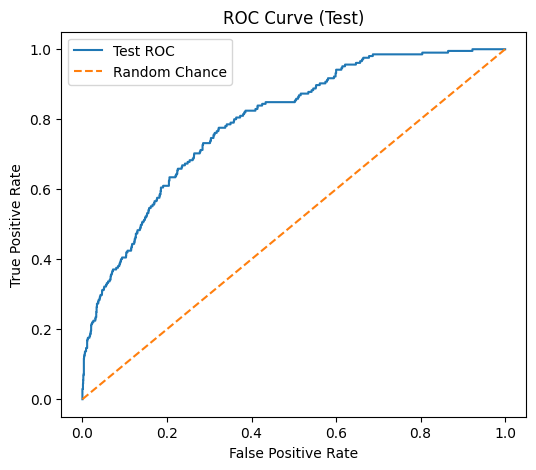

{'test': {'accuracy': 0.7791386803634927,
  'balanced_accuracy': np.float64(0.7130318981607702),
  'roc_auc': np.float64(0.7943701109410063),
  'roc_curve': {'fpr': array([0.        , 0.        , 0.        , 0.00128977, 0.00128977,
          0.00171969, 0.00171969, 0.00214961, 0.00214961, 0.00300946,
          0.00300946, 0.00343938, 0.00343938, 0.0038693 , 0.0038693 ,
          0.00472915, 0.00472915, 0.00558899, 0.00558899, 0.00601892,
          0.00601892, 0.00859845, 0.00859845, 0.01117799, 0.01117799,
          0.01160791, 0.01160791, 0.01289768, 0.01289768, 0.01676698,
          0.01676698, 0.01805675, 0.01805675, 0.01934652, 0.01934652,
          0.01977644, 0.01977644, 0.02063629, 0.02063629, 0.02106621,
          0.02106621, 0.0227859 , 0.0227859 , 0.02579536, 0.02579536,
          0.03052451, 0.03052451, 0.03095443, 0.03095443, 0.03267412,
          0.03267412, 0.03353396, 0.03353396, 0.03439381, 0.03439381,
          0.03740327, 0.03740327, 0.03783319, 0.03783319, 0.04041273

In [8]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, all_feature_columns)